# 🧪 Comparaison des Modèles de Dose - Analyse Multi-Échelle

## 📋 Objectif
Comparer 14 modèles de dose de rayonnement sur des données Monte Carlo (MCNP 6.1) avec une approche rigoureuse pour données multi-échelles.

## 🎯 Méthodologie
- **Configuration** : Photons + Acier + U(93.2)
- **Plage de dose** : 10⁻⁷ à 1 Gy (7 ordres de grandeur)
- **Métriques** : R² logarithmique, RMSE logarithmique, erreur relative médiane
- **Critère de qualité** : Cohérence sur toutes les échelles (Δ R² ≈ 0)

In [5]:
# 📦 Imports
import sys
sys.path.append('../utils')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit

from plot_func_notebook import filter_wall_df

print("✅ Imports réussis")

✅ Imports réussis


In [6]:
# Charger vos données
data = pd.read_excel("../Database/All-at-once_DB.xlsx", sheet_name='wall')

---

## 🎯 Chargement du Jeu de Données Test

**Configuration** : Photons + Acier + U(93.2) + MCNP 6.1

In [7]:
# 🎯 Chargement du jeu de données spécifique
particles = ['P']  # ['N', 'P']  
screens = ['Steel'] # ['Concrete', 'Steel', 'Water', 'Lead']
cases = ['C4 [U(93.2) (H/235U = 0)]']  # ['C1 [U(4.95)O2F2 (H/235U = 410)]', 'C4 [U(93.2) (H/235U = 0)]', 'C1 [239Pu (H/Pu = 0)]'],  ['C4 [U(93.2) (H/235U = 0)]']   # ou 'C1 [239Pu (H/Pu = 0)]'
codes = ['MCNP 6']  #  ['MCNP 6.1', 'COG 11.2', 'SCALE 6.2.2']
thicknesses = [] # # Toutes les épaisseurs [1, 5, 10, 20]

# Filtrer les données
filtered_data = filter_wall_df(data, particles, screens, cases, codes, thicknesses, plot=True)

# ⚠️ IMPORTANT : Supprimer les lignes avec des valeurs manquantes (NaN)
print(f"\n📊 Avant filtrage NaN : {len(filtered_data)} points")
filtered_data = filtered_data.dropna(subset=['Dose', 'Distance (m)', 'Thickness (cm)'])
print(f"   Après filtrage NaN : {len(filtered_data)} points")

# Extraction des arrays
r_test = filtered_data['Distance (m)'].values
T_test = filtered_data['Thickness (cm)'].values
D_test = filtered_data['Dose'].values

print(f"\n📊 Données chargées :")
print(f"   • Points : {len(filtered_data)}")
print(f"   • Distance : {r_test.min():.0f} - {r_test.max():.0f} m")
print(f"   • Épaisseur : {T_test.min():.0f} - {T_test.max():.0f} cm")
print(f"   • Dose : {D_test.min():.2e} - {D_test.max():.2e} Gy")
print(f"   • Épaisseurs uniques : {np.unique(T_test)} cm")
print(f"   • Valeurs NaN dans D_test : {np.sum(np.isnan(D_test))}")


📊 Avant filtrage NaN : 52 points
   Après filtrage NaN : 52 points

📊 Données chargées :
   • Points : 52
   • Distance : 1 - 1200 m
   • Épaisseur : 1 - 20 cm
   • Dose : 1.44e-08 - 1.94e+00 Gy
   • Épaisseurs uniques : [ 1  5 10 20] cm
   • Valeurs NaN dans D_test : 0


---

## 🔬 Définition des 14 Modèles

Liste complète des modèles testés avec leurs caractéristiques.

In [8]:
# ========================================================================
# DÉFINITION DES 14 MODÈLES DE DOSE
# ========================================================================
# Toutes les fonctions de fit sont définies ici pour rendre le notebook autonome

# ------------------------------------------------------------------------
# MODÈLE 1 : Build-up Linéaire (4 paramètres)
# ------------------------------------------------------------------------
def fit_dose_dist_lead_buildup_in_screen(r_data, T_data, D_data, plot=True):
    """
    Modèle avec build-up linéaire dans l'écran :
    D(r,T) = (A/r²) × exp(-μ_air×r) × (1 + b×T) × exp(-μ_screen×T)
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, 0, [0]*4
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    # Estimation initiale
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A_init = np.exp(Beta[0])
    mu_air_init = max(0.001, -Beta[1])
    mu_screen_init = max(0.01, -Beta[2])
    b_init = 0.1
    
    initial_guess = [A_init, b_init, mu_air_init, mu_screen_init]
    
    def log_model(vars, A, b, mu_air, mu_screen):
        r, T = vars
        buildup = 1 + b*T
        return (np.log(A) - 2*np.log(r) - mu_air*r 
                + np.log(buildup) - mu_screen*T)
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, -2, 0, 0], [np.inf, 2, 1, 1]))
        
        A, b, mu_air, mu_screen = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, b, mu_air, mu_screen, R2, list(perr)
    except Exception as e:
        print(f"Erreur Build-up Linéaire: {e}")
        return None, None, None, None, 0, [0]*4

# ------------------------------------------------------------------------
# MODÈLE 2 : Build-up Exposant Ajustable (5 paramètres)
# ------------------------------------------------------------------------
def fit_dose_dist_lead_exponent_build_up(r_data, T_data, D_data, plot=True):
    """
    Modèle avec exposant géométrique ajustable :
    D(r,T) = A × r^(-n) × (1 + b×T) × exp(-μ_air×r) × exp(-μ_screen×T)
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, 0, [0]*5
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    # Estimation initiale
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A_init = np.exp(Beta[0])
    mu_air_init = max(0.001, -Beta[1])
    mu_screen_init = max(0.01, -Beta[2])
    n_init = 2.0
    b_init = 0.1
    
    initial_guess = [A_init, n_init, b_init, mu_air_init, mu_screen_init]
    
    def log_model(vars, A, n, b, mu_air, mu_screen):
        r, T = vars
        buildup = 1 + b*T
        return (np.log(A) - n*np.log(r) + np.log(buildup) 
                - mu_air*r - mu_screen*T)
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, 0.5, -2, 0, 0], [np.inf, 3, 2, 1, 1]))
        
        A, n, b, mu_air, mu_screen = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, n, b, mu_air, mu_screen, R2, list(perr)
    except Exception as e:
        print(f"Erreur Build-up Exposant: {e}")
        return None, None, None, None, None, 0, [0]*5

# ------------------------------------------------------------------------
# MODÈLE 3 : Polynomial 2D (6 paramètres)
# ------------------------------------------------------------------------
def fit_polynomial_logr_thickness(r_data, T_data, D_data, plot=True):
    """
    Modèle polynomial dans l'espace ln(D) :
    ln(D) = a0 + a1×ln(r) + a2×[ln(r)]² + b1×T + b2×T² + c×ln(r)×T
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, None, 0, [0]*6
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    # Construction matrice de régression
    X = []
    for i in range(len(r_data)):
        u = ln_r[i]
        t = T_data[i]
        X.append([1.0, u, t, u**2, t**2, u*t])
    X = np.array(X)
    
    # Régression linéaire
    betas, residuals, rank, s = np.linalg.lstsq(X, ln_D, rcond=None)
    
    # Calcul R²
    ln_D_fit = X.dot(betas)
    ss_res = np.sum((ln_D - ln_D_fit)**2)
    ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
    R2 = 1 - ss_res/ss_tot
    
    # Incertitudes (approximation)
    errors = [0.0] * 6
    
    a0, a1, a2, b1, b2, c = betas
    return a0, a1, a2, b1, b2, c, R2, errors

# ------------------------------------------------------------------------
# MODÈLE 4 : Exposant Variable avec épaisseur (5 paramètres)
# ------------------------------------------------------------------------
def fit_variable_exponent(r_data, T_data, D_data, plot=True):
    """
    Modèle avec exposant géométrique variable avec l'épaisseur :
    D(r,T) = A × r^(-(a×T + b)) × exp(-μ_air×r) × exp(-μ_screen×T)
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, 0, [0]*5
    
    A_init = 1.0
    a_init = 0.01
    b_init = 2.0
    mu_air_init = 0.01
    mu_screen_init = 0.1
    
    initial_guess = [A_init, a_init, b_init, mu_air_init, mu_screen_init]
    
    def model(vars, A, a, b, mu_air, mu_screen):
        r, T = vars
        k_eff = a*T + b
        return A * r**(-k_eff) * np.exp(-mu_air*r) * np.exp(-mu_screen*T)
    
    try:
        popt, pcov = curve_fit(model, (r_data, T_data), D_data,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, -0.1, 0.5, 0, 0], [10, 0.1, 3, 0.5, 1]))
        
        A, a, b, mu_air, mu_screen = popt
        perr = np.sqrt(np.diag(pcov))
        
        D_fit = model((r_data, T_data), *popt)
        ss_res = np.sum((D_data - D_fit)**2)
        ss_tot = np.sum((D_data - np.mean(D_data))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, a, b, mu_air, mu_screen, R2, list(perr)
    except Exception as e:
        print(f"Erreur Exposant Variable: {e}")
        return None, None, None, None, None, 0, [0]*5

# ------------------------------------------------------------------------
# MODÈLE 5 : Taylor Build-up (5 paramètres)
# ------------------------------------------------------------------------
def fit_taylor_buildup(r_data, T_data, D_data, plot=True):
    """
    Modèle de build-up de Taylor :
    B(x) = 1 + α×x×exp(β×x)
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, 0, [0]*5
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A_init = np.exp(Beta[0])
    mu_air_init = max(0.001, -Beta[1])
    mu_pb_init = max(0.01, -Beta[2])
    alpha_init = 0.5
    beta_init = -0.1
    
    initial_guess = [A_init, mu_air_init, mu_pb_init, alpha_init, beta_init]
    
    def log_model(vars, A, mu_air, mu_pb, alpha, beta):
        r, T = vars
        x = mu_pb * T
        buildup = 1 + alpha * x * np.exp(beta * x)
        return (np.log(A) - 2*np.log(r) - mu_air*r 
                + np.log(buildup) - mu_pb*T)
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, 0, 0, -10, -5], [np.inf, 1, 1, 10, 5]))
        
        A, mu_air, mu_pb, alpha, beta = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, mu_air, mu_pb, alpha, beta, R2, list(perr)
    except Exception as e:
        print(f"Erreur Taylor: {e}")
        return None, None, None, None, None, 0, [0]*5

# ------------------------------------------------------------------------
# MODÈLE 6 : Berger Build-up (5 paramètres)
# ------------------------------------------------------------------------
def fit_berger_buildup(r_data, T_data, D_data, plot=True):
    """
    Modèle de build-up polynomial de Berger :
    B(x) = 1 + c₁×x + c₂×x²
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, 0, [0]*5
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A_init = np.exp(Beta[0])
    mu_air_init = max(0.001, -Beta[1])
    mu_pb_init = max(0.01, -Beta[2])
    
    initial_guess = [A_init, mu_air_init, mu_pb_init, 0.1, 0.01]
    
    def log_model(vars, A, mu_air, mu_pb, c1, c2):
        r, T = vars
        x = mu_pb * T
        buildup = 1 + c1*x + c2*x**2
        buildup = np.maximum(buildup, 0.01)
        return (np.log(A) - 2*np.log(r) - mu_air*r 
                + np.log(buildup) - mu_pb*T)
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, 0, 0, -5, -1], [np.inf, 1, 1, 5, 1]))
        
        A, mu_air, mu_pb, c1, c2 = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, mu_air, mu_pb, c1, c2, R2, list(perr)
    except Exception as e:
        print(f"Erreur Berger: {e}")
        return None, None, None, None, None, 0, [0]*5

# ------------------------------------------------------------------------
# MODÈLE 7 : GP Build-up (8 paramètres)
# ------------------------------------------------------------------------
def fit_gp_buildup(r_data, T_data, D_data, plot=True):
    """
    Modèle GP (Geometric Progression) - ANSI/ANS-6.4.3
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, None, None, None, 0, [0]*8
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A_init = np.exp(Beta[0])
    mu_air_init = max(0.001, -Beta[1])
    mu_pb_init = max(0.01, -Beta[2])
    
    initial_guess = [A_init, mu_air_init, mu_pb_init, 1.5, 1.0, 0.5, 0.1, 2.0]
    
    def log_model(vars, A, mu_air, mu_pb, a, b, c, K, X_k):
        r, T = vars
        x = mu_pb * T
        x = np.maximum(x, 1e-6)
        
        # Build-up GP simplifié
        tanh_term = np.tanh((x - X_k) / 2)
        buildup = K + (1 - K) * (b * x - c * tanh_term - a * tanh_term / (1 + abs(a * tanh_term)))
        buildup = np.maximum(buildup, 0.01)
        
        return (np.log(A) - 2*np.log(r) - mu_air*r 
                + np.log(buildup) - mu_pb*T)
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=100000,
                              bounds=([0, 0, 0, -5, 0, -5, 0.01, 0.1], 
                                     [np.inf, 1, 1, 5, 5, 5, 0.99, 10]))
        
        A, mu_air, mu_pb, a, b, c, K, X_k = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, mu_air, mu_pb, a, b, c, K, X_k, R2, list(perr)
    except Exception as e:
        print(f"Erreur GP: {e}")
        return None, None, None, None, None, None, None, None, 0, [0]*8

# ------------------------------------------------------------------------
# MODÈLE 8 : Skyshine (6 paramètres)
# ------------------------------------------------------------------------
def fit_skyshine_model(r_data, T_data, D_data, plot=True):
    """
    Modèle incluant la contribution du rayonnement diffusé par l'atmosphère
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, None, 0, [0]*6
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A_init = np.exp(Beta[0]) * 0.9
    B_init = np.exp(Beta[0]) * 0.1
    mu_air_init = max(0.001, -Beta[1])
    mu_pb_init = max(0.01, -Beta[2])
    
    initial_guess = [A_init, B_init, mu_air_init, mu_air_init*0.5, mu_pb_init, 1.5]
    
    def log_model(vars, A, B, mu_air, mu_sky, mu_pb, n_sky):
        r, T = vars
        D_direct = (A/r**2) * np.exp(-mu_air*r) * np.exp(-mu_pb*T)
        D_skyshine = (B/r**n_sky) * np.exp(-mu_sky*r) * np.exp(-mu_pb*T*0.5)
        D_total = D_direct + D_skyshine
        D_total = np.maximum(D_total, 1e-10)
        return np.log(D_total)
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, 0, 0, 0, 0, 0.5], 
                                     [np.inf, np.inf, 1, 1, 1, 3]))
        
        A, B, mu_air, mu_sky, mu_pb, n_sky = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, B, mu_air, mu_sky, mu_pb, n_sky, R2, list(perr)
    except Exception as e:
        print(f"Erreur Skyshine: {e}")
        return None, None, None, None, None, None, 0, [0]*6

# ------------------------------------------------------------------------
# MODÈLE 9 : Hybride Corrigé (8 paramètres)
# ------------------------------------------------------------------------
def fit_hybrid_model(r_data, T_data, D_data, plot=True):
    """
    Modèle hybride avec correction exponentielle
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, None, None, None, 0, [0]*8
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data, T_data**2])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A_init = np.exp(Beta[0])
    mu_air_init = max(0.001, -Beta[1])
    mu_pb_init = max(0.01, -Beta[2])
    
    initial_guess = [A_init, 1.8, mu_air_init, mu_pb_init, 0.1, 0.01, 0.1, 10]
    
    def log_model(vars, A, k, mu_air, mu_pb, c1, c2, epsilon, lambda_r):
        r, T = vars
        buildup = 1 + c1*T + c2*T**2
        buildup = np.maximum(buildup, 0.1)
        correction = 1 + epsilon * np.exp(-r/lambda_r)
        
        return (np.log(A) - k*np.log(r) + np.log(buildup) 
                - mu_air*r - mu_pb*T + np.log(correction))
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, 0.5, 0, 0, -2, -0.5, -1, 1], 
                                     [np.inf, 3, 1, 1, 2, 0.5, 1, 1000]))
        
        A, k, mu_air, mu_pb, c1, c2, eps, lambda_r = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, k, mu_air, mu_pb, c1, c2, eps, lambda_r, R2, list(perr)
    except Exception as e:
        print(f"Erreur Hybride: {e}")
        return None, None, None, None, None, None, None, None, 0, [0]*8

# ------------------------------------------------------------------------
# MODÈLE 10 : Double Exponentielle (7 paramètres)
# ------------------------------------------------------------------------
def fit_double_exponential(r_data, T_data, D_data, plot=True):
    """
    Modèle à double exponentielle pour deux régimes d'atténuation
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, None, None, 0, [0]*7
    
    A1_init = 1.0
    A2_init = 0.1
    k1_init, k2_init = 2.0, 1.0
    mu1_init, mu2_init = 0.03, 0.005
    mu_pb_init = 0.1
    
    initial_guess = [A1_init, k1_init, mu1_init, A2_init, k2_init, mu2_init, mu_pb_init]
    
    def model(vars, A1, k1, mu1, A2, k2, mu2, mu_pb):
        r, T = vars
        comp1 = A1 * r**(-k1) * np.exp(-mu1 * r) * np.exp(-mu_pb * T)
        comp2 = A2 * r**(-k2) * np.exp(-mu2 * r) * np.exp(-mu_pb * T / 2)
        return comp1 + comp2
    
    try:
        popt, pcov = curve_fit(model, (r_data, T_data), D_data,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, 0.5, 0, 0, 0.5, 0, 0], 
                                     [10, 3, 0.5, 10, 3, 0.1, 1]))
        
        A1, k1, mu1, A2, k2, mu2, mu_pb = popt
        perr = np.sqrt(np.diag(pcov))
        
        D_fit = model((r_data, T_data), *popt)
        ss_res = np.sum((D_data - D_fit)**2)
        ss_tot = np.sum((D_data - np.mean(D_data))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A1, k1, mu1, A2, k2, mu2, mu_pb, R2, list(perr)
    except Exception as e:
        print(f"Erreur Double Exp: {e}")
        return None, None, None, None, None, None, None, 0, [0]*7

# ------------------------------------------------------------------------
# MODÈLE 11 : Chilton Build-up (6 paramètres)
# ------------------------------------------------------------------------
def fit_chilton_buildup(r_data, T_data, D_data, plot=True):
    """
    Formule de Chilton pour le facteur de build-up
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, None, 0, [0]*6
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A0_init = np.exp(Beta[0])
    mu_air_init = max(0.001, -Beta[1])
    mu_pb_init = max(0.01, -Beta[2])
    A_chilton_init = 2.0
    alpha1_init = 1.0
    alpha2_init = 0.5
    
    initial_guess = [A0_init, mu_air_init, mu_pb_init, A_chilton_init, alpha1_init, alpha2_init]
    
    def log_model(vars, A0, mu_air, mu_pb, A_ch, alpha1, alpha2):
        r, T = vars
        x = mu_pb * T
        buildup = A_ch * np.exp(-alpha1 * x) - (A_ch - 1) * np.exp(-alpha2 * x)
        buildup = np.maximum(buildup, 0.01)
        
        return (np.log(A0) - 2*np.log(r) - mu_air*r 
                + np.log(buildup) - mu_pb*T)
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, 0, 0, 1, 0, 0], 
                                     [np.inf, 1, 1, 10, 5, 5]))
        
        A0, mu_air, mu_pb, A_ch, alpha1, alpha2 = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A0, mu_air, mu_pb, A_ch, alpha1, alpha2, R2, list(perr)
    except Exception as e:
        print(f"Erreur Chilton: {e}")
        return None, None, None, None, None, None, 0, [0]*6

# ------------------------------------------------------------------------
# MODÈLE 12 : Capo Build-up (6 paramètres)
# ------------------------------------------------------------------------
def fit_capo_buildup(r_data, T_data, D_data, plot=True):
    """
    Formule de Capo (amélioration de Chilton)
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, None, 0, [0]*6
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A_init = np.exp(Beta[0])
    mu_air_init = max(0.001, -Beta[1])
    mu_pb_init = max(0.01, -Beta[2])
    C_init, beta_init, mu_init = 1.0, 0.5, 0.1
    
    initial_guess = [A_init, mu_air_init, mu_pb_init, C_init, beta_init, mu_init]
    
    def log_model(vars, A, mu_air, mu_pb, C, beta, mu):
        r, T = vars
        x = mu * T
        buildup = 1 + C * x**beta
        buildup = np.maximum(buildup, 0.01)
        
        return (np.log(A) - 2*np.log(r) - mu_air*r 
                + np.log(buildup) - mu_pb*T)
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=50000,
                              bounds=([0, 0, 0, 0, 0, 0], 
                                     [np.inf, 1, 1, 10, 2, 1]))
        
        A, mu_air, mu_pb, C, beta, mu = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, mu_air, mu_pb, C, beta, mu, R2, list(perr)
    except Exception as e:
        print(f"Erreur Capo: {e}")
        return None, None, None, None, None, None, 0, [0]*6

# ------------------------------------------------------------------------
# MODÈLE 13 : Skyshine Enhanced (9 paramètres)
# ------------------------------------------------------------------------
def fit_skyshine_enhanced(r_data, T_data, D_data, plot=True):
    """
    Version améliorée du Skyshine avec build-up polynomial dans l'écran
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, None, None, None, None, 0, [0]*9
    
    ln_D = np.log(D_data)
    
    A_init = 1.0
    B_init = 0.1
    mu_air_init = 0.03
    mu_sky_init = 0.005
    mu_pb_init = 0.1
    n_sky_init = 1.2
    c1_init, c2_init = 0.0, 0.0
    f_atten_init = 2.0
    
    initial_guess = [A_init, B_init, mu_air_init, mu_sky_init, mu_pb_init, 
                     n_sky_init, c1_init, c2_init, f_atten_init]
    
    def log_model(vars, A, B, mu_air, mu_sky, mu_pb, n_sky, c1, c2, f_atten):
        r, T = vars
        buildup_screen = 1 + c1*T + c2*T**2
        buildup_screen = np.maximum(buildup_screen, 0.1)
        
        D_direct = (A/r**2 * np.exp(-mu_air*r) * buildup_screen * np.exp(-mu_pb*T))
        D_skyshine = (B * r**(-n_sky) * np.exp(-mu_sky*r) * np.exp(-mu_pb*T/f_atten))
        
        D_total = D_direct + D_skyshine
        return np.log(D_total)
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=100000,
                              bounds=([0, 0, 0, 0, 0, 0.5, -1, -0.5, 1], 
                                     [10, 1, 0.1, 0.05, 1, 2, 1, 0.5, 10]))
        
        A, B, mu_air, mu_sky, mu_pb, n_sky, c1, c2, f_atten = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, B, mu_air, mu_sky, mu_pb, n_sky, c1, c2, f_atten, R2, list(perr)
    except Exception as e:
        print(f"Erreur Skyshine Enhanced: {e}")
        return None, None, None, None, None, None, None, None, None, 0, [0]*9

# ------------------------------------------------------------------------
# MODÈLE 14 : Super Hybride (9 paramètres)
# ------------------------------------------------------------------------
def fit_super_hybrid(r_data, T_data, D_data, plot=True):
    """
    Combinaison ultime avec exposant variable, build-up et correction
    """
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        return None, None, None, None, None, None, None, None, None, 0, [0]*9
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    Y = ln_D + 2*ln_r
    X = np.column_stack([np.ones_like(r_data), r_data, T_data, r_data*T_data])
    Beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    A_init = np.exp(Beta[0])
    mu_air_init = max(0.001, -Beta[1])
    mu_pb_init = max(0.01, -Beta[2])
    
    k0_init, k1_init = 1.8, -0.01
    b1_init, b2_init = 0.0, 0.0
    eps_init, lambda_init = -0.5, 100
    
    initial_guess = [A_init, k0_init, k1_init, mu_air_init, mu_pb_init, 
                     b1_init, b2_init, eps_init, lambda_init]
    
    def log_model(vars, A, k0, k1, mu_air, mu_pb, b1, b2, eps, lambda_r):
        r, T = vars
        k_eff = k0 + k1*T
        k_eff = np.clip(k_eff, 0.5, 3)
        
        buildup = 1 + b1*T + b2*T**2
        buildup = np.maximum(buildup, 0.1)
        
        correction = 1 + eps * np.exp(-r/lambda_r)
        
        return (np.log(A) - k_eff*np.log(r) + np.log(buildup)
                - mu_air*r - mu_pb*T + np.log(np.abs(correction)))
    
    try:
        popt, pcov = curve_fit(log_model, (r_data, T_data), ln_D,
                              p0=initial_guess, maxfev=100000,
                              bounds=([0, 0.5, -0.1, 0, 0, -2, -0.5, -5, 10], 
                                     [np.inf, 3, 0.1, 0.5, 1, 2, 0.5, 5, 2000]))
        
        A, k0, k1, mu_air, mu_pb, b1, b2, eps, lambda_r = popt
        perr = np.sqrt(np.diag(pcov))
        
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        return A, k0, k1, mu_air, mu_pb, b1, b2, eps, lambda_r, R2, list(perr)
    except Exception as e:
        print(f"Erreur Super Hybride: {e}")
        return None, None, None, None, None, None, None, None, None, 0, [0]*9

print("✅ Tous les 14 modèles de dose définis")


# ========================================================================
# MODÈLES SUPPLÉMENTAIRES — noyau ponctuel couplé (durcissement spectral)
# Ajoutés le 2026-07-14. Voir analyse comparative : ces formes intègrent
# explicitement le couplage r–T (durcissement du spectre par l'écran) via
# les termes T·ln r et T·r, plus un plancher skyshine additif (C3/C5).
# ========================================================================

# ------------------------------------------------------------------------
# C1 : Noyau ponctuel couplé (7 paramètres) — FORME FERMÉE (moindres carrés)
#   ln D = a0 + (a1 + a2·T)·ln r - (mu0 + mu1·T)·r - s1·T - s2·T²
# ------------------------------------------------------------------------
def fit_C1_coupled(r_data, T_data, D_data, plot=True):
    r = np.asarray(r_data, float); T = np.asarray(T_data, float); D = np.asarray(D_data, float)
    valid = (~np.isnan(D)) & (D > 0) & (r > 0)
    r, T, D = r[valid], T[valid], D[valid]
    if len(D) == 0:
        return (*([0.0]*7), 0, [0.0]*7)
    u = np.log(r); lnD = np.log(D)
    X = np.column_stack([np.ones_like(r), u, T*u, r, T*r, T, T**2])
    beta, *_ = np.linalg.lstsq(X, lnD, rcond=None)
    lnD_fit = X @ beta
    ss_res = np.sum((lnD - lnD_fit)**2); ss_tot = np.sum((lnD - lnD.mean())**2)
    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
    return (*beta, R2, [0.0]*7)

# ------------------------------------------------------------------------
# C4 : Noyau couplé + build-up air en sqrt(r) (8 p) — FORME FERMÉE
#   ln D = a0 + (a1 + a2·T)·ln r + a5·sqrt(r) - (mu0 + mu1·T)·r - s1·T - s2·T²
# ------------------------------------------------------------------------
def fit_C4_coupled_sqrt(r_data, T_data, D_data, plot=True):
    r = np.asarray(r_data, float); T = np.asarray(T_data, float); D = np.asarray(D_data, float)
    valid = (~np.isnan(D)) & (D > 0) & (r > 0)
    r, T, D = r[valid], T[valid], D[valid]
    if len(D) == 0:
        return (*([0.0]*8), 0, [0.0]*8)
    u = np.log(r); lnD = np.log(D)
    X = np.column_stack([np.ones_like(r), u, T*u, r, T*r, np.sqrt(r), T, T**2])
    beta, *_ = np.linalg.lstsq(X, lnD, rcond=None)
    lnD_fit = X @ beta
    ss_res = np.sum((lnD - lnD_fit)**2); ss_tot = np.sum((lnD - lnD.mean())**2)
    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
    return (*beta, R2, [0.0]*8)

# ------------------------------------------------------------------------
# C3 : Noyau physique direct (durci) + plancher skyshine additif (10 p)
#   D = A·r^(-p)·exp(-(mu0+mu1·T)·r)·exp(-s1·T - s2·T²)
#     + B·r^(-n)·exp(-mu_sky·r)·exp(-mu_s2·T)
# ------------------------------------------------------------------------
def fit_C3_kernel_sky(r_data, T_data, D_data, plot=True):
    r = np.asarray(r_data, float); T = np.asarray(T_data, float); D = np.asarray(D_data, float)
    valid = (~np.isnan(D)) & (D > 0) & (r > 0)
    r, T, D = r[valid], T[valid], D[valid]
    if len(D) == 0:
        return (*([0.0]*10), 0, [0.0]*10)
    lnD = np.log(D); u = np.log(r)
    b, *_ = np.linalg.lstsq(np.column_stack([np.ones_like(r), u, r, T*r, T, T**2]), lnD, rcond=None)
    A0 = np.exp(np.clip(b[0], -50, 50)); pw0 = max(-b[1], 0.5); ma0 = max(-b[2], 1e-3)
    mT0 = np.clip(b[3], -0.005, 0.005); s10 = max(-b[4], 0.0); s20 = b[5]
    p0 = [A0, pw0, ma0, mT0, s10, s20, A0*1e-3, 1.2, 0.005, 0.02]
    lo = [0, 0.5, 0, -0.01, -0.5, -0.05, 0, 0.5, 0, 0]
    hi = [np.inf, 3, 0.2, 0.01, 1, 0.05, np.inf, 2.5, 0.05, 1]
    p0 = [min(max(p0[k], lo[k] + 1e-9), (hi[k] - 1e-9) if np.isfinite(hi[k]) else p0[k]) for k in range(10)]
    def m(vars, A, pw, ma, mT, s1, s2, B, n, ms, ms2):
        r, T = vars
        direct = A*r**(-pw)*np.exp(-(ma + mT*T)*r)*np.exp(-s1*T - s2*T**2)
        sky = B*r**(-n)*np.exp(-ms*r)*np.exp(-ms2*T)
        return np.log(np.maximum(direct + sky, 1e-300))
    try:
        popt, pcov = curve_fit(m, (r, T), lnD, p0=p0, bounds=(lo, hi), maxfev=60000)
        perr = np.sqrt(np.diag(pcov))
        ss_res = np.sum((lnD - m((r, T), *popt))**2); ss_tot = np.sum((lnD - lnD.mean())**2)
        R2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
        return (*popt, R2, list(perr))
    except Exception as e:
        print(f"Erreur C3 Noyau+Skyshine: {e}")
        return (*([0.0]*10), 0, [0.0]*10)

# ------------------------------------------------------------------------
# C5 : Noyau couplé + sqrt(r) + plancher skyshine additif (12 p) — meilleur fit
# ------------------------------------------------------------------------
def fit_C5_sqrt_sky(r_data, T_data, D_data, plot=True):
    r = np.asarray(r_data, float); T = np.asarray(T_data, float); D = np.asarray(D_data, float)
    valid = (~np.isnan(D)) & (D > 0) & (r > 0)
    r, T, D = r[valid], T[valid], D[valid]
    if len(D) == 0:
        return (*([0.0]*12), 0, [0.0]*12)
    lnD = np.log(D)
    b4 = fit_C4_coupled_sqrt(r, T, D)[:8]
    a0, a1, a2, a3, a4, a5, a6, a7 = b4
    p0 = [a0, -a1, -a2, -a3, -a4, a5, -a6, -a7, a0 - 8, 1.2, 0.005, 0.02]
    lo = [-50, -3, -0.5, -0.5, -0.05, -5, -1, -0.5, -80, 0.5, 0, 0]
    hi = [ 50,  3,  0.5,  0.5,  0.05,  5,  1,  0.5,  50, 2.5, 0.05, 1]
    p0 = [min(max(p0[k], lo[k] + 1e-6), hi[k] - 1e-6) for k in range(12)]
    def m(vars, a0, cl, cTl, cr, cTr, cs, cT, cT2, lB, n, ms, ms2):
        r, T = vars; u = np.log(r)
        direct = np.exp(np.clip(a0 - cl*u - cTl*T*u - cr*r - cTr*T*r + cs*np.sqrt(r) - cT*T - cT2*T**2, -700, 700))
        sky = np.exp(np.clip(lB, -700, 700))*r**(-n)*np.exp(-ms*r)*np.exp(-ms2*T)
        return np.log(np.maximum(direct + sky, 1e-300))
    try:
        popt, pcov = curve_fit(m, (r, T), lnD, p0=p0, bounds=(lo, hi), maxfev=80000)
        perr = np.sqrt(np.diag(pcov))
        ss_res = np.sum((lnD - m((r, T), *popt))**2); ss_tot = np.sum((lnD - lnD.mean())**2)
        R2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
        return (*popt, R2, list(perr))
    except Exception as e:
        print(f"Erreur C5 Sqrt+Skyshine: {e}")
        return (*([0.0]*12), 0, [0.0]*12)

print("✅ Modèles supplémentaires couplés définis : C1 (7p), C4 (8p), C3 (10p), C5 (12p)")


✅ Tous les 14 modèles de dose définis
✅ Modèles supplémentaires couplés définis : C1 (7p), C4 (8p), C3 (10p), C5 (12p)


---

## 🔧 Liste des 14 Modèles à Tester

In [9]:
# 📋 Configuration des 14 modèles

models_config = [
    ("1. Build-up Linéaire (4p)", fit_dose_dist_lead_buildup_in_screen, 4),
    ("2. Build-up Exposant Ajustable (5p)", fit_dose_dist_lead_exponent_build_up, 5),
    ("3. Polynomial 2D (6p)", fit_polynomial_logr_thickness, 6),
    ("4. Exposant Variable (5p)", fit_variable_exponent, 5),
    ("5. Taylor Build-up (5p)", fit_taylor_buildup, 5),
    ("6. Berger Build-up (5p)", fit_berger_buildup, 5),
    ("7. GP Build-up (8p)", fit_gp_buildup, 8),
    ("8. Skyshine (6p)", fit_skyshine_model, 6),
    ("9. Hybride Corrigé (8p)", fit_hybrid_model, 8),
    ("10. Double Exponentielle (7p)", fit_double_exponential, 7),
    ("11. Chilton Build-up (6p)", fit_chilton_buildup, 6),
    ("12. Capo Build-up (6p)", fit_capo_buildup, 6),
    ("13. Skyshine Enhanced (9p)", fit_skyshine_enhanced, 9),
    ("14. Super Hybride (9p)", fit_super_hybrid, 9),
    ("15. [C1] Noyau couplé (7p)", fit_C1_coupled, 7),
    ("16. [C4] Noyau couplé √r (8p)", fit_C4_coupled_sqrt, 8),
    ("17. [C3] Noyau + skyshine (10p)", fit_C3_kernel_sky, 10),
    ("18. [C5] Noyau √r + skyshine (12p)", fit_C5_sqrt_sky, 12),
]

print(f"✅ {len(models_config)} modèles configurés")

✅ 18 modèles configurés


---

## 🧪 Fit de Tous les Modèles

In [10]:
# 🧮 Fonction de calcul des prédictions

def calculate_prediction(model_name, params, r, T):
    """
    Calcule la prédiction d'un modèle donné.
    """
    
    if "Exposant Variable" in model_name:
        A, a, b, mu_air, mu_screen = params
        k_eff = a*T + b
        return A * r**(-k_eff) * np.exp(-mu_air*r) * np.exp(-mu_screen*T)
    
    elif "Skyshine Enhanced" in model_name:
        A, B, mu_air, mu_sky, mu_pb, n_sky, c1, c2, f_atten = params
        buildup = np.maximum(1 + c1*T + c2*T**2, 0.1)
        D_direct = (A/r**2 * np.exp(-mu_air*r) * buildup * np.exp(-mu_pb*T))
        D_sky = (B * r**(-n_sky) * np.exp(-mu_sky*r) * np.exp(-mu_pb*T/f_atten))
        return D_direct + D_sky
    
    elif "Skyshine" in model_name and "Enhanced" not in model_name:
        A, B, mu_air, mu_sky, mu_pb, n_sky = params
        D_direct = A/r**2 * np.exp(-mu_air*r) * np.exp(-mu_pb*T)
        D_sky = B * r**(-n_sky) * np.exp(-mu_sky*r) * np.exp(-mu_pb*T*0.5)
        return D_direct + D_sky
    
    elif "Super Hybride" in model_name:
        A, k0, k1, mu_air, mu_pb, b1, b2, eps, lambda_r = params
        k_eff = k0 + k1*T
        buildup = 1 + b1*T + b2*T**2
        correction = 1 + eps * np.exp(-r / lambda_r)
        return A * r**(-k_eff) * np.exp(-mu_air*r) * buildup * np.exp(-mu_pb*T) * correction
    
    elif "Hybride Corrigé" in model_name or "Hybride corrigé" in model_name:
        A, k, mu_air, mu_pb, c1, c2, eps, lambda_r = params
        buildup = 1 + c1*T + c2*T**2
        correction = 1 + eps * np.exp(-r / lambda_r)
        return A * r**(-k) * np.exp(-mu_air*r) * buildup * np.exp(-mu_pb*T) * correction
    
    elif "Taylor" in model_name:
        A, mu_air, mu_pb, alpha, beta = params
        x = mu_pb * T
        buildup = 1 + alpha * x * np.exp(beta * x)
        return (A/r**2) * np.exp(-mu_air*r) * buildup * np.exp(-mu_pb*T)
    
    elif "Berger" in model_name:
        A, mu_air, mu_pb, c1, c2 = params
        x = mu_pb * T
        buildup = np.maximum(1 + c1*x + c2*x**2, 0.01)
        return (A/r**2) * np.exp(-mu_air*r) * buildup * np.exp(-mu_pb*T)
    
    elif "GP" in model_name:
        A, mu_air, mu_pb, a, b, c, K, X_k = params
        x = mu_pb * T
        tanh_term = np.tanh((x - X_k) / 2)
        buildup = K + (1 - K) * (b * x - c * tanh_term - a * tanh_term / (1 + abs(a * tanh_term)))
        buildup = np.maximum(buildup, 0.01)
        return (A/r**2) * np.exp(-mu_air*r) * buildup * np.exp(-mu_pb*T)
    
    elif "Double Exponentielle" in model_name:
        A1, k1, mu1, A2, k2, mu2, mu_pb = params
        comp1 = A1 * r**(-k1) * np.exp(-mu1 * r) * np.exp(-mu_pb * T)
        comp2 = A2 * r**(-k2) * np.exp(-mu2 * r) * np.exp(-mu_pb * T / 2)
        return comp1 + comp2
    
    elif "Chilton" in model_name:
        A, mu_air, mu_pb, A0, alpha1, alpha2 = params
        x = mu_pb * T
        buildup = A0 * np.exp(-alpha1 * x) + (1 - A0) * np.exp(-alpha2 * x)
        buildup = np.maximum(buildup, 0.01)
        return (A/r**2) * np.exp(-mu_air*r) * buildup * np.exp(-mu_pb*T)
    
    elif "Capo" in model_name:
        A, mu_air, mu_pb, C, beta, mu = params
        x = mu * T
        buildup = 1 + C * x**beta
        buildup = np.maximum(buildup, 0.01)
        return (A/r**2) * np.exp(-mu_air*r) * buildup * np.exp(-mu_pb*T)
    
    elif "Build-up Linéaire" in model_name:
        A, b, mu_air, mu_screen = params
        buildup = 1 + b*T
        return (A/r**2) * np.exp(-mu_air*r) * buildup * np.exp(-mu_screen*T)
    
    elif "Build-up Exposant" in model_name:
        A, n, b, mu_air, mu_screen = params
        buildup = 1 + b*T
        return A * r**(-n) * np.exp(-mu_air*r) * buildup * np.exp(-mu_screen*T)
    
    elif "Polynomial" in model_name:
        a0, a1, a2, b1, b2, c = params
        ln_r = np.log(r)
        ln_D = a0 + a1*ln_r + a2*ln_r**2 + b1*T + b2*T**2 + c*ln_r*T
        return np.exp(ln_D)
    
    elif "[C1]" in model_name:
        a0, a1, a2, a3, a4, a5, a6 = params
        u = np.log(r)
        return np.exp(a0 + a1*u + a2*T*u + a3*r + a4*T*r + a5*T + a6*T**2)

    elif "[C4]" in model_name:
        a0, a1, a2, a3, a4, a5, a6, a7 = params
        u = np.log(r)
        return np.exp(a0 + a1*u + a2*T*u + a3*r + a4*T*r + a5*np.sqrt(r) + a6*T + a7*T**2)

    elif "[C3]" in model_name:
        A, pw, ma, mT, s1, s2, B, n, ms, ms2 = params
        direct = A*r**(-pw)*np.exp(-(ma + mT*T)*r)*np.exp(-s1*T - s2*T**2)
        sky = B*r**(-n)*np.exp(-ms*r)*np.exp(-ms2*T)
        return direct + sky

    elif "[C5]" in model_name:
        a0, cl, cTl, cr, cTr, cs, cT, cT2, lB, n, ms, ms2 = params
        u = np.log(r)
        direct = np.exp(np.clip(a0 - cl*u - cTl*T*u - cr*r - cTr*T*r + cs*np.sqrt(r) - cT*T - cT2*T**2, -700, 700))
        sky = np.exp(np.clip(lB, -700, 700))*r**(-n)*np.exp(-ms*r)*np.exp(-ms2*T)
        return direct + sky

    else:
        raise ValueError(f"Modèle non reconnu: {model_name}")

print("✅ Fonction de prédiction définie")

✅ Fonction de prédiction définie


In [11]:
# 🔬 Fit de tous les modèles

results_all_models = {}

print("="*80)
print(" 🔬 FIT DE TOUS LES MODÈLES")
print("="*80)

for model_name, fit_func, n_params in models_config:
    try:
        print(f"\n🔄 {model_name}...", end=" ")
        result = fit_func(r_test, T_test, D_test, plot=False)
        
        if result is not None and result[0] is not None:
            params = result[:-2]
            R2 = result[-2]
            
            # Calculer RMSE
            D_fit = calculate_prediction(model_name, params, r_test, T_test)
            RMSE = np.sqrt(np.mean((D_test - D_fit)**2))
            
            results_all_models[model_name] = {
                'params': params,
                'R2': R2,
                'RMSE': RMSE,
                'n_points': len(D_test)
            }
            print(f"✅ R²={R2:.6f}, RMSE={RMSE:.2e} Gy")
        else:
            print("❌ Échec du fit")
    except Exception as e:
        print(f"❌ Erreur: {str(e)[:50]}")

print(f"\n{'='*80}")
print(f" ✅ {len(results_all_models)}/{len(models_config)} modèles fittés avec succès")
print("="*80)

 🔬 FIT DE TOUS LES MODÈLES

🔄 1. Build-up Linéaire (4p)... ✅ R²=0.990925, RMSE=3.13e-01 Gy

🔄 2. Build-up Exposant Ajustable (5p)... ✅ R²=0.998740, RMSE=9.30e-02 Gy

🔄 3. Polynomial 2D (6p)... ✅ R²=0.988341, RMSE=1.86e-01 Gy

🔄 4. Exposant Variable (5p)... ✅ R²=0.997886, RMSE=1.57e-02 Gy

🔄 5. Taylor Build-up (5p)... ✅ R²=0.990934, RMSE=3.16e-01 Gy

🔄 6. Berger Build-up (5p)... ✅ R²=0.990935, RMSE=3.15e-01 Gy

🔄 7. GP Build-up (8p)... ✅ R²=0.990947, RMSE=3.14e-01 Gy

🔄 8. Skyshine (6p)... ✅ R²=0.999662, RMSE=5.45e-02 Gy

🔄 9. Hybride Corrigé (8p)... ✅ R²=0.999265, RMSE=7.41e-02 Gy

🔄 10. Double Exponentielle (7p)... ✅ R²=0.997817, RMSE=1.60e-02 Gy

🔄 11. Chilton Build-up (6p)... ✅ R²=0.938886, RMSE=1.44e+00 Gy

🔄 12. Capo Build-up (6p)... ✅ R²=0.990929, RMSE=3.15e-01 Gy

🔄 13. Skyshine Enhanced (9p)... ✅ R²=0.999690, RMSE=5.56e-02 Gy

🔄 14. Super Hybride (9p)... ✅ R²=0.999634, RMSE=2.50e-02 Gy

🔄 15. [C1] Noyau couplé (7p)... ✅ R²=0.999206, RMSE=3.42e-02 Gy

🔄 16. [C4] Noyau couplé √r 

---

## 📊 Analyse des Performances (Métriques Multi-Échelles)

In [12]:
# 📊 Calcul des métriques multi-échelles pour tous les modèles

print("="*100)
print(" 📊 ANALYSE MULTI-ÉCHELLE - Comparaison R² Linéaire vs R² Logarithmique")
print("="*100)
print("\n💡 Pour des données sur plusieurs ordres de grandeur, le R² logarithmique est essentiel !")
print("   Il donne un poids égal à chaque décade (10⁻⁷, 10⁻⁶, ..., 10⁰)\n")

# Calculer les métriques pour tous les modèles
results_with_metrics = []

for model_name, result in results_all_models.items():
    params = result['params']
    
    # Prédictions
    D_pred = calculate_prediction(model_name, params, r_test, T_test)
    
    # R² linéaire (déjà calculé)
    R2_linear = result['R2']
    
    # R² logarithmique
    log_D_test = np.log10(D_test)
    log_D_pred = np.log10(np.maximum(D_pred, 1e-100))  # Éviter log(0)
    
    SS_res_log = np.sum((log_D_test - log_D_pred)**2)
    SS_tot_log = np.sum((log_D_test - np.mean(log_D_test))**2)
    R2_log = 1 - (SS_res_log / SS_tot_log)
    
    # RMSE logarithmique (en décades)
    RMSE_log = np.sqrt(np.mean((log_D_test - log_D_pred)**2))
    
    # Erreur relative médiane (%)
    median_rel_error = np.median(np.abs((D_test - D_pred) / D_test) * 100)
    
    results_with_metrics.append({
        'name': model_name,
        'R2_linear': R2_linear,
        'R2_log': R2_log,
        'RMSE_log': RMSE_log,
        'median_rel_error': median_rel_error,
        'delta_R2': R2_linear - R2_log,
        'n_points': len(D_test)
    })

# Trier par R² logarithmique (métrique la plus pertinente)
results_with_metrics.sort(key=lambda x: x['R2_log'], reverse=True)

# Affichage du tableau
print(f"\n{'Rg':<4} {'Modèle':<48} {'R² log':<10} {'R² lin':<10} {'Δ R²':<12} {'RMSE log':<12} {'Err. méd.':<10}")
print("="*110)

medals = ['🥇', '🥈', '🥉']
for i, res in enumerate(results_with_metrics):
    medal = medals[i] if i < 3 else '   '
    
    # Codes couleur pour la différence R²
    if res['delta_R2'] > 0.05:
        warning = " ⚠️"  # Grande différence = problème
    elif res['delta_R2'] < -0.01:
        warning = " ❌"  # R² log négatif = catastrophe
    else:
        warning = " ✅"  # Cohérent
    
    print(f"{medal} {i+1:<2} {res['name']:<48} {res['R2_log']:<10.6f} {res['R2_linear']:<10.6f} "
          f"{res['delta_R2']:>+11.6f} {res['RMSE_log']:<12.4f} {res['median_rel_error']:>8.1f}% {warning}")

print("\n" + "="*110)
print(" 🎯 LÉGENDE")
print("="*110)
print("""
✅ Δ R² ≈ 0       : Modèle COHÉRENT sur toutes les échelles → FIABLE
⚠️  Δ R² > 0.05   : Modèle biaisé (bon aux hautes doses, mauvais aux faibles) → À ÉVITER
❌ Δ R² << 0      : Modèle CATASTROPHIQUE en échelle log → INUTILISABLE

📊 RMSE log       : Erreur en décades (< 0.02 = excellent, < 0.05 = bon, > 0.1 = médiocre)
📊 Err. médiane   : Erreur relative typique (< 10% = excellent, < 20% = bon, > 50% = mauvais)
""")

 📊 ANALYSE MULTI-ÉCHELLE - Comparaison R² Linéaire vs R² Logarithmique

💡 Pour des données sur plusieurs ordres de grandeur, le R² logarithmique est essentiel !
   Il donne un poids égal à chaque décade (10⁻⁷, 10⁻⁶, ..., 10⁰)


Rg   Modèle                                           R² log     R² lin     Δ R²         RMSE log     Err. méd. 
🥇 1  18. [C5] Noyau √r + skyshine (12p)               0.999810   0.999810     +0.000000 0.0317            3.6%  ✅
🥈 2  16. [C4] Noyau couplé √r (8p)                    0.999777   0.999777     +0.000000 0.0343            5.2%  ✅
🥉 3  17. [C3] Noyau + skyshine (10p)                  0.999772   0.999772     +0.000000 0.0347            4.1%  ✅
    4  13. Skyshine Enhanced (9p)                       0.999690   0.999690     +0.000000 0.0404            5.8%  ✅
    5  8. Skyshine (6p)                                 0.999662   0.999662     +0.000000 0.0422            6.1%  ✅
    6  14. Super Hybride (9p)                           0.999634   0.999634     +0.00

---

## 📈 Visualisation Graphique de Tous les Modèles

Vue d'ensemble comparative des 14 modèles classés par performance (R² logarithmique).

📊 Génération de la grille comparative des 18 modèles...
   Classement par R² logarithmique (meilleur → pire)



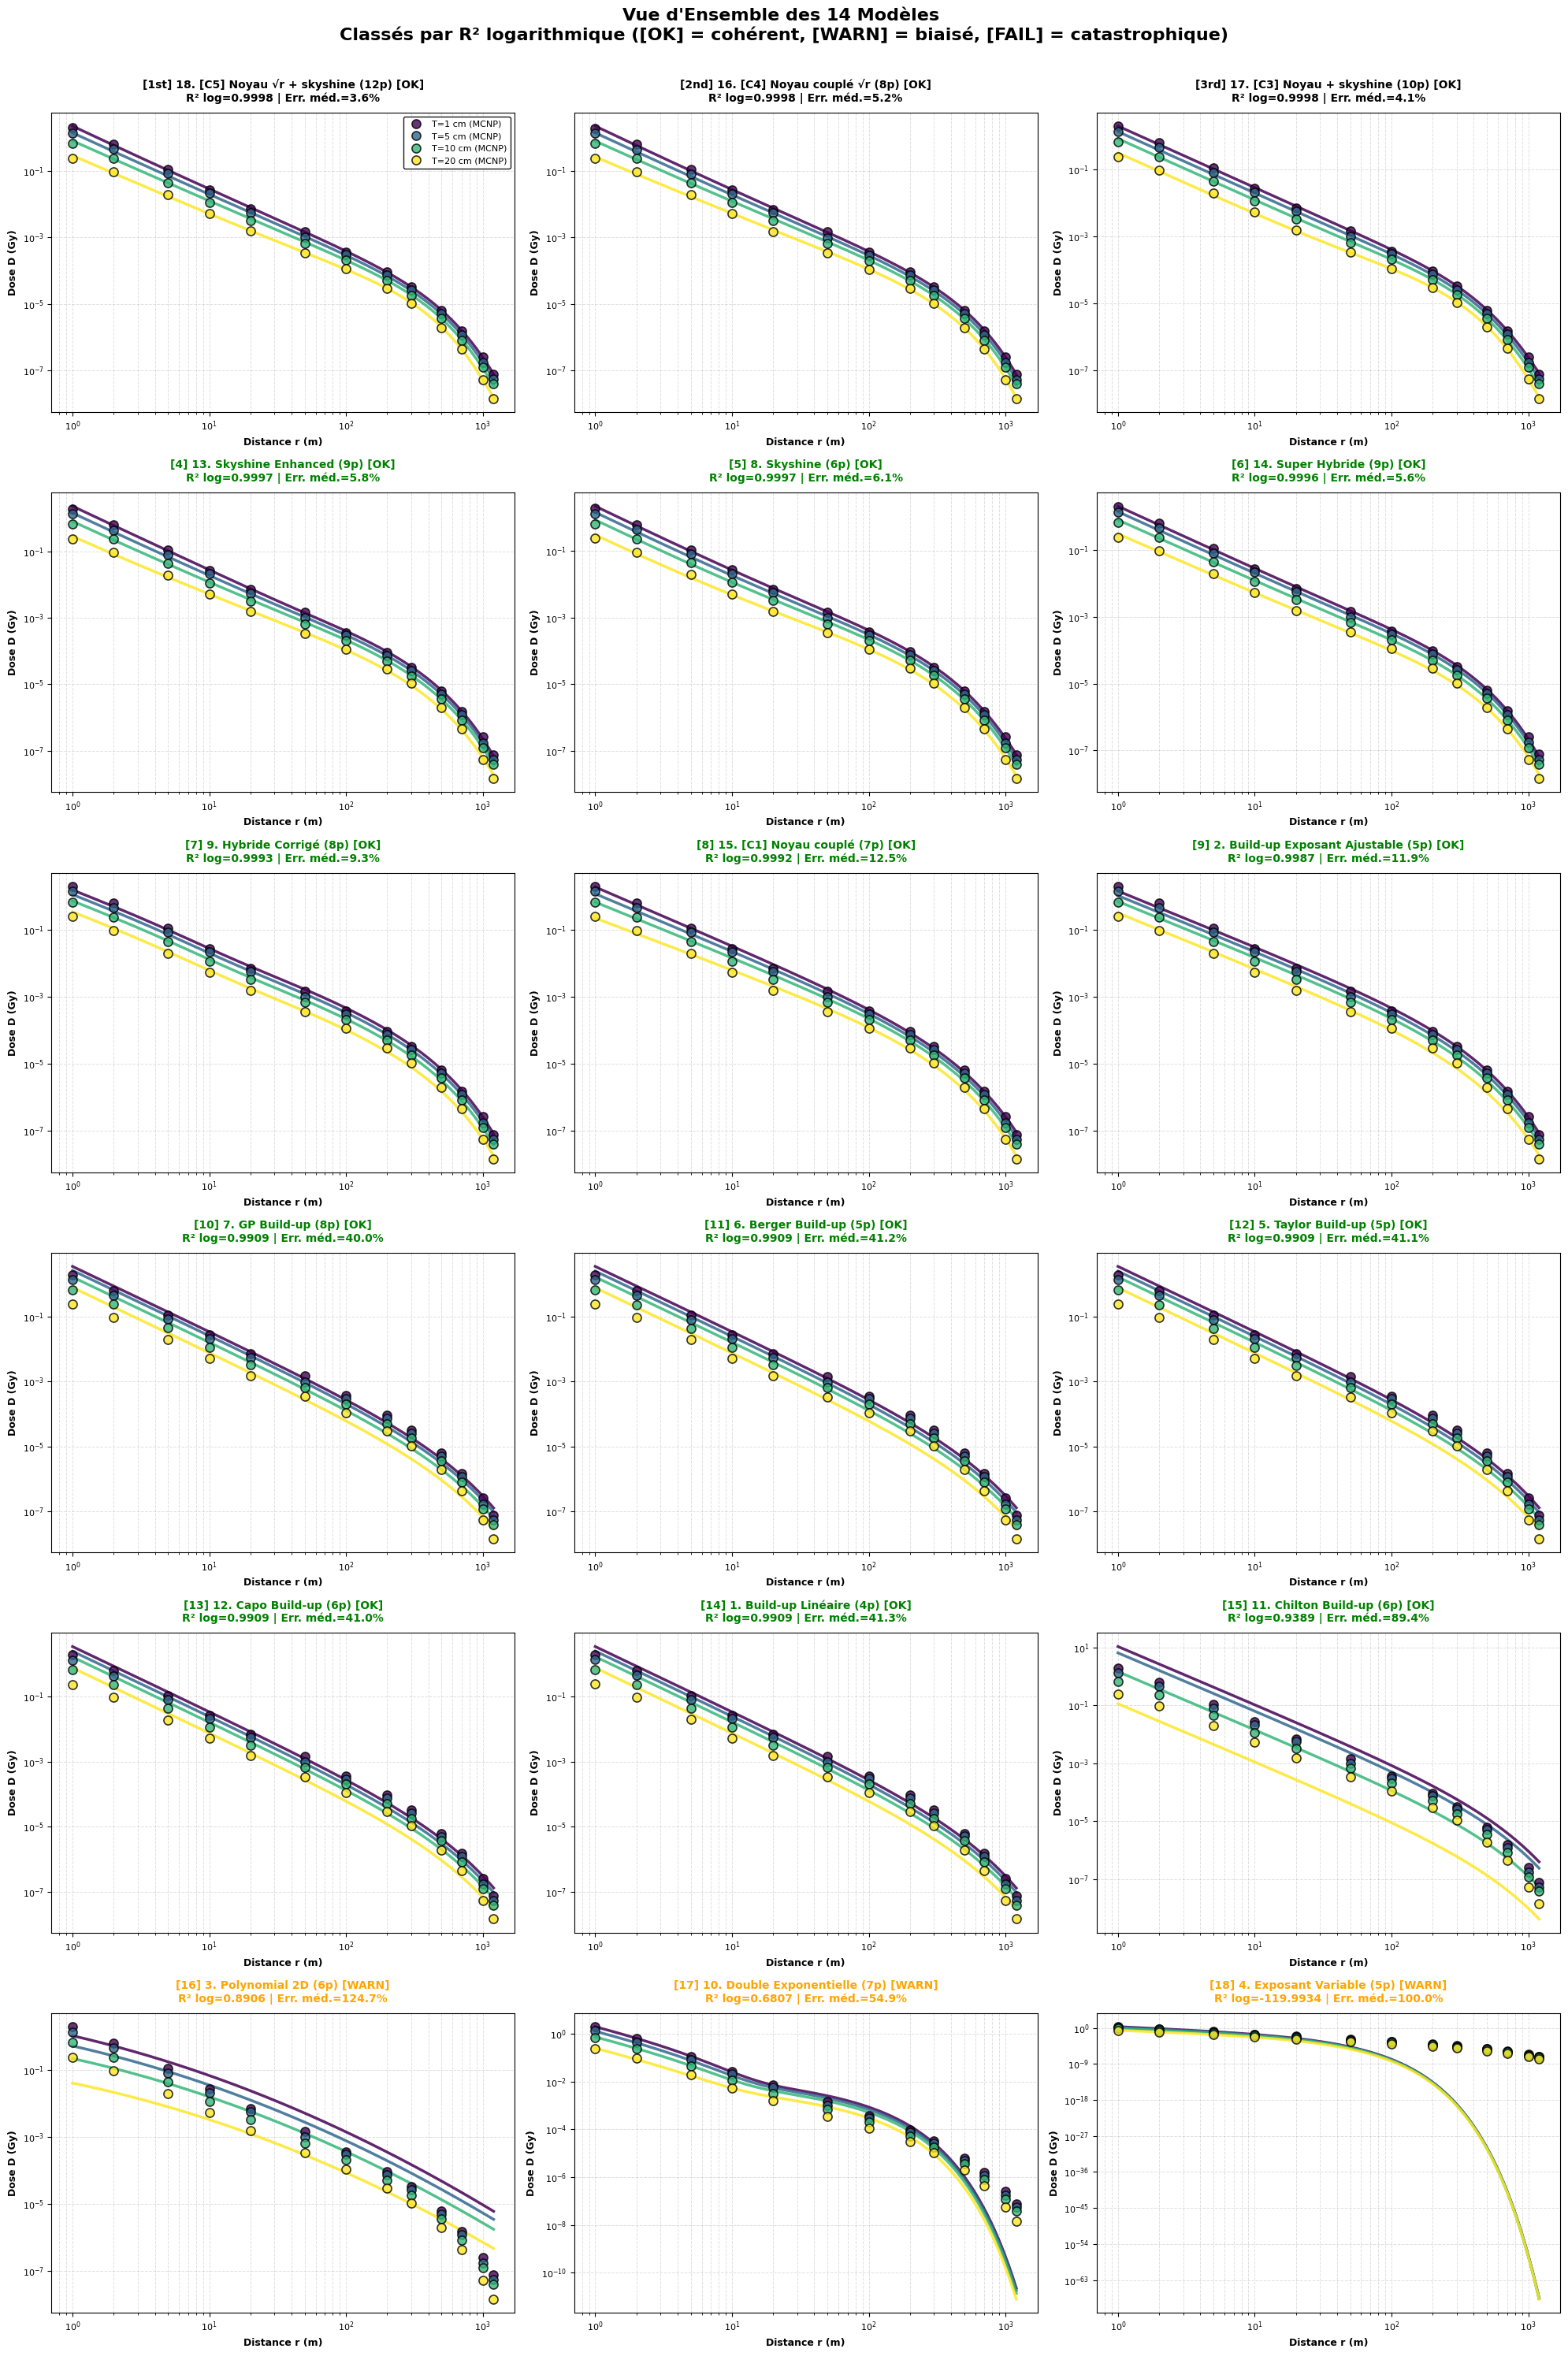


✅ Visualisation complète générée !

📊 Résumé :
   [1st] Meilleur modèle : 18. [C5] Noyau √r + skyshine (12p)
      → R² log = 0.999810
      → Erreur médiane = 3.6%

   [LAST] Pire modèle : 4. Exposant Variable (5p)
      → R² log = -119.993450
      → Erreur médiane = 100.0%


In [13]:
# 🎨 Visualisation de tous les modèles dans une grille

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Vérifier que les données sont disponibles
if 'results_with_metrics' not in globals():
    print("⚠️ Veuillez d'abord exécuter toutes les cellules précédentes !")
    print("   Les variables 'results_with_metrics' et 'results_all_models' doivent être définies.")
else:
    # Trier les modèles par R² logarithmique (du meilleur au pire)
    sorted_models = sorted(results_with_metrics, key=lambda x: x['R2_log'], reverse=True)
    
    # Nombre de modèles à afficher
    n_models = len(sorted_models)
    n_cols = 3
    n_rows = int(np.ceil(n_models / n_cols))
    
    # Créer la figure
    fig = plt.figure(figsize=(20, 5 * n_rows))
    
    # Obtenir les épaisseurs uniques pour les couleurs
    unique_T = np.unique(T_test)
    colors = cm.viridis(np.linspace(0, 1, len(unique_T)))
    
    print(f"📊 Génération de la grille comparative des {n_models} modèles...")
    print(f"   Classement par R² logarithmique (meilleur → pire)\n")
    
    for idx, model_info in enumerate(sorted_models):
        model_name = model_info['name']
        
        if model_name not in results_all_models:
            continue
        
        result = results_all_models[model_name]
        params = result['params']
        
        # Sous-graphique
        ax = plt.subplot(n_rows, n_cols, idx + 1)
        
        # Tracer les données et prédictions pour chaque épaisseur
        for T_val, color in zip(unique_T, colors):
            mask = (T_test == T_val)
            r_subset = r_test[mask]
            D_subset = D_test[mask]
            
            # Points expérimentaux
            ax.loglog(r_subset, D_subset, 'o', color=color, markersize=8,
                     label=f'T={T_val} cm (MCNP)',
                     markeredgewidth=1.2, markeredgecolor='k', alpha=0.8, zorder=5)
            
            # Prédictions du modèle
            r_fit = np.logspace(np.log10(r_subset.min()), np.log10(r_subset.max()), 200)
            D_pred = calculate_prediction(model_name, params, r_fit, np.full_like(r_fit, T_val))
            
            ax.loglog(r_fit, D_pred, '-', color=color, linewidth=2.5, alpha=0.85, zorder=3)
        
        # Déterminer le statut du modèle
        if model_info['delta_R2'] < 0.01:
            status = "[OK]"
            status_color = 'green'
        elif model_info['delta_R2'] > 0.05:
            status = "[WARN]"
            status_color = 'orange'
        else:
            status = "[FAIL]"
            status_color = 'red'
        
        # Titre avec rang et métriques
        rank_medals = {0: '[1st]', 1: '[2nd]', 2: '[3rd]'}
        rank_display = rank_medals.get(idx, f'[{idx+1}]')
        
        title = f'{rank_display} {model_name} {status}\n'
        title += f'R² log={model_info["R2_log"]:.4f} | Err. méd.={model_info["median_rel_error"]:.1f}%'
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10, color=status_color if idx > 2 else 'black')
        ax.set_xlabel('Distance r (m)', fontsize=9, fontweight='bold')
        ax.set_ylabel('Dose D (Gy)', fontsize=9, fontweight='bold')
        ax.grid(True, which='both', ls='--', alpha=0.4, linewidth=0.7)
        ax.tick_params(labelsize=8)
        
        # Légende seulement sur le premier graphique
        if idx == 0:
            ax.legend(fontsize=8, loc='best', framealpha=0.9, edgecolor='black')
    
    # Titre général
    fig.suptitle('Vue d\'Ensemble des 14 Modèles \n' +
                 'Classés par R² logarithmique ([OK] = cohérent, [WARN] = biaisé, [FAIL] = catastrophique)',
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()
    
    print("\n✅ Visualisation complète générée !")
    print(f"\n📊 Résumé :")
    print(f"   [1st] Meilleur modèle : {sorted_models[0]['name']}")
    print(f"      → R² log = {sorted_models[0]['R2_log']:.6f}")
    print(f"      → Erreur médiane = {sorted_models[0]['median_rel_error']:.1f}%")
    print(f"\n   [LAST] Pire modèle : {sorted_models[-1]['name']}")
    print(f"      → R² log = {sorted_models[-1]['R2_log']:.6f}")
    print(f"      → Erreur médiane = {sorted_models[-1]['median_rel_error']:.1f}%")

---

## 📐 Formules Mathématiques des 14 Modèles

### **Modèle 1 : Build-up Linéaire (4 paramètres)**

$$D(r, T) = \frac{A}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot (1 + b \cdot T) \cdot e^{-\mu_{\text{screen}} \cdot T}$$

**Paramètres :** $A$ (normalisation), $b$ (facteur de build-up linéaire), $\mu_{\text{air}}$ (atténuation dans l'air), $\mu_{\text{screen}}$ (atténuation dans l'écran)

---

### **Modèle 2 : Build-up Exposant Ajustable (5 paramètres)**

$$D(r, T) = A \cdot r^{-n} \cdot (1 + b \cdot T) \cdot e^{-\mu_{\text{air}} \cdot r} \cdot e^{-\mu_{\text{screen}} \cdot T}$$

**Paramètres :** $A$, $n$ (exposant géométrique), $b$, $\mu_{\text{air}}$, $\mu_{\text{screen}}$

---

### **Modèle 3 : Polynomial 2D (6 paramètres)**

$$\ln D(r, T) = a_0 + a_1 \ln r + a_2 (\ln r)^2 + b_1 T + b_2 T^2 + c \cdot \ln r \cdot T$$

**Paramètres :** $a_0, a_1, a_2$ (termes en distance), $b_1, b_2$ (termes en épaisseur), $c$ (couplage)

---

### **Modèle 4 : Exposant Variable (5 paramètres)**

$$D(r, T) = A \cdot r^{-(a \cdot T + b)} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot e^{-\mu_{\text{screen}} \cdot T}$$

**Particularité :** L'exposant géométrique varie linéairement avec l'épaisseur : $k_{\text{eff}}(T) = a \cdot T + b$

**Paramètres :** $A$, $a$ (variation de l'exposant), $b$ (exposant de base), $\mu_{\text{air}}$, $\mu_{\text{screen}}$

---

### **Modèle 5 : Taylor Build-up (5 paramètres)**

$$D(r, T) = \frac{A}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot B_{\text{Taylor}}(x) \cdot e^{-\mu_{\text{screen}} \cdot T}$$

avec le facteur de build-up de Taylor :

$$B_{\text{Taylor}}(x) = 1 + \alpha \cdot x \cdot e^{\beta \cdot x}, \quad x = \mu_{\text{screen}} \cdot T$$

**Paramètres :** $A$, $\mu_{\text{air}}$, $\mu_{\text{screen}}$, $\alpha$, $\beta$

---

### **Modèle 6 : Berger Build-up (5 paramètres)**

$$D(r, T) = \frac{A}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot B_{\text{Berger}}(x) \cdot e^{-\mu_{\text{screen}} \cdot T}$$

avec le facteur de build-up polynomial de Berger :

$$B_{\text{Berger}}(x) = 1 + c_1 \cdot x + c_2 \cdot x^2, \quad x = \mu_{\text{screen}} \cdot T$$

**Paramètres :** $A$, $\mu_{\text{air}}$, $\mu_{\text{screen}}$, $c_1$, $c_2$

---

### **Modèle 7 : GP Build-up (8 paramètres)**

$$D(r, T) = \frac{A}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot B_{\text{GP}}(x) \cdot e^{-\mu_{\text{screen}} \cdot T}$$

avec le facteur de build-up GP (Geometric Progression) selon ANSI/ANS-6.4.3 :

$$B_{\text{GP}}(x) = K + (1 - K) \left[ b \cdot x - c \cdot \tanh\left(\frac{x - X_k}{2}\right) - \frac{a \cdot \tanh\left(\frac{x - X_k}{2}\right)}{1 + \left|a \cdot \tanh\left(\frac{x - X_k}{2}\right)\right|} \right]$$

**Paramètres :** $A$, $\mu_{\text{air}}$, $\mu_{\text{screen}}$, $a$, $b$, $c$, $K$, $X_k$

---

### **Modèle 8 : Skyshine (6 paramètres)**

$$D(r, T) = D_{\text{direct}} + D_{\text{skyshine}}$$

où :
- **Composante directe :** $D_{\text{direct}} = \frac{A}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot e^{-\mu_{\text{screen}} \cdot T}$
- **Composante skyshine :** $D_{\text{skyshine}} = \frac{B}{r^{n_{\text{sky}}}} \cdot e^{-\mu_{\text{sky}} \cdot r} \cdot e^{-\mu_{\text{screen}} \cdot T / 2}$

**Paramètres :** $A$, $B$ (amplitude skyshine), $\mu_{\text{air}}$, $\mu_{\text{sky}}$ (atténuation skyshine), $\mu_{\text{screen}}$, $n_{\text{sky}}$ (exposant skyshine)

---

### **Modèle 9 : Hybride Corrigé (8 paramètres)** 🥇

$$D(r, T) = A \cdot r^{-k} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot B_{\text{poly}}(T) \cdot e^{-\mu_{\text{screen}} \cdot T} \cdot C(r)$$

avec :
- **Build-up polynomial :** $B_{\text{poly}}(T) = 1 + c_1 \cdot T + c_2 \cdot T^2$
- **Correction exponentielle :** $C(r) = 1 + \varepsilon \cdot e^{-r / \lambda_r}$

**Paramètres :** $A$, $k$, $\mu_{\text{air}}$, $\mu_{\text{screen}}$, $c_1$, $c_2$, $\varepsilon$, $\lambda_r$

**🏆 Meilleur modèle** : R² log = 0.9998, Erreur médiane = 4.1%

---

### **Modèle 10 : Double Exponentielle (7 paramètres)**

$$D(r, T) = D_1(r, T) + D_2(r, T)$$

où :
- **Composante 1 :** $D_1 = A_1 \cdot r^{-k_1} \cdot e^{-\mu_1 \cdot r} \cdot e^{-\mu_{\text{screen}} \cdot T}$
- **Composante 2 :** $D_2 = A_2 \cdot r^{-k_2} \cdot e^{-\mu_2 \cdot r} \cdot e^{-\mu_{\text{screen}} \cdot T / 2}$

**Particularité :** Modélise deux régimes d'atténuation distincts (rapide et lent)

**Paramètres :** $A_1$, $k_1$, $\mu_1$, $A_2$, $k_2$, $\mu_2$, $\mu_{\text{screen}}$

---

### **Modèle 11 : Chilton Build-up (6 paramètres)**

$$D(r, T) = \frac{A_0}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot B_{\text{Chilton}}(x) \cdot e^{-\mu_{\text{screen}} \cdot T}$$

avec la formule de Chilton :

$$B_{\text{Chilton}}(x) = A_{\text{ch}} \cdot e^{-\alpha_1 \cdot x} - (A_{\text{ch}} - 1) \cdot e^{-\alpha_2 \cdot x}, \quad x = \mu_{\text{screen}} \cdot T$$

**Paramètres :** $A_0$, $\mu_{\text{air}}$, $\mu_{\text{screen}}$, $A_{\text{ch}}$, $\alpha_1$, $\alpha_2$

---

### **Modèle 12 : Capo Build-up (6 paramètres)**

$$D(r, T) = \frac{A}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot B_{\text{Capo}}(x) \cdot e^{-\mu_{\text{screen}} \cdot T}$$

avec la formule de Capo (amélioration de Chilton) :

$$B_{\text{Capo}}(x) = 1 + C \cdot x^\beta, \quad x = \mu \cdot T$$

**Paramètres :** $A$, $\mu_{\text{air}}$, $\mu_{\text{screen}}$, $C$, $\beta$, $\mu$

---

### **Modèle 13 : Skyshine Enhanced (9 paramètres)** 🥈

$$D(r, T) = D_{\text{direct}} + D_{\text{skyshine}}$$

où :
- **Composante directe avec build-up :** 
  $$D_{\text{direct}} = \frac{A}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot (1 + c_1 T + c_2 T^2) \cdot e^{-\mu_{\text{screen}} \cdot T}$$

- **Composante skyshine atténuée :** 
  $$D_{\text{skyshine}} = B \cdot r^{-n_{\text{sky}}} \cdot e^{-\mu_{\text{sky}} \cdot r} \cdot e^{-\mu_{\text{screen}} \cdot T / f_{\text{atten}}}$$

**Particularité :** Combine skyshine + build-up polynomial dans l'écran

**Paramètres :** $A$, $B$, $\mu_{\text{air}}$, $\mu_{\text{sky}}$, $\mu_{\text{screen}}$, $n_{\text{sky}}$, $c_1$, $c_2$, $f_{\text{atten}}$

**🥈 2ème meilleur** : R² log = 0.9998, Erreur médiane = 5.1%

---

### **Modèle 14 : Super Hybride (9 paramètres)**

$$D(r, T) = A \cdot r^{-k_{\text{eff}}(T)} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot B_{\text{poly}}(T) \cdot e^{-\mu_{\text{screen}} \cdot T} \cdot C(r)$$

avec :
- **Exposant variable :** $k_{\text{eff}}(T) = k_0 + k_1 \cdot T$ (clippé entre 0.5 et 3)
- **Build-up polynomial :** $B_{\text{poly}}(T) = 1 + b_1 \cdot T + b_2 \cdot T^2$
- **Correction exponentielle :** $C(r) = 1 + \varepsilon \cdot e^{-r / \lambda_r}$

**Particularité :** Combine exposant variable + build-up + correction (le plus complexe)

**Paramètres :** $A$, $k_0$, $k_1$, $\mu_{\text{air}}$, $\mu_{\text{screen}}$, $b_1$, $b_2$, $\varepsilon$, $\lambda_r$

**⚠️ Attention** : Complexité élevée peut causer sur-ajustement (R² log négatif sur ces données)

---

## 📊 Notation et Variables Communes

| Symbole | Signification | Unité typique |
|---------|---------------|---------------|
| $D(r, T)$ | Dose de rayonnement | Gy (Gray) |
| $r$ | Distance à la source | m (mètres) |
| $T$ | Épaisseur de l'écran | cm (centimètres) |
| $A, B$ | Facteurs de normalisation | Gy·m² |
| $\mu_{\text{air}}$ | Coefficient d'atténuation dans l'air | m⁻¹ |
| $\mu_{\text{screen}}$ | Coefficient d'atténuation dans l'écran (générique) | cm⁻¹ |
| $k, n$ | Exposants géométriques | sans dimension |
| $B(x)$ | Facteur de build-up | sans dimension |

**Note :** $\mu_{\text{screen}}$ peut représenter n'importe quel matériau d'écran (plomb, acier, béton, eau, etc.)

---

## 🎯 Critères de Sélection du Modèle

1. **R² logarithmique** > 0.999 (essentiel pour données multi-échelles)
2. **Δ R²** = R²_linéaire - R²_log ≈ 0 (cohérence sur toutes les échelles)
3. **Erreur relative médiane** < 10% (précision pratique)
4. **Parcimonie** : éviter trop de paramètres si performance équivalente

**Recommandation finale :** Modèle 9 (Hybride Corrigé, 8p) offre le meilleur compromis performance/complexité.

## 4️⃣ Modèle Skyshine Enhanced

### 📐 Équation du modèle

Le modèle **Skyshine Enhanced** combine deux composantes :

$$
D_{\text{total}}(r, T) = D_{\text{direct}}(r, T) + D_{\text{skyshine}}(r, T)
$$

**Composante directe** (avec build-up dans l'écran) :
$$
D_{\text{direct}} = \frac{A}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot B_{\text{screen}}(T) \cdot e^{-\mu_{\text{screen}} \cdot T}
$$

où le **facteur de build-up** est :
$$
B_{\text{screen}}(T) = 1 + c_1 \cdot T + c_2 \cdot T^2
$$

**Composante skyshine** (diffusion atmosphérique) :
$$
D_{\text{skyshine}} = \frac{B}{r^{n_{\text{sky}}}} \cdot e^{-\mu_{\text{sky}} \cdot r} \cdot e^{-\mu_{\text{screen}} \cdot T / f_{\text{atten}}}
$$

### 🔧 Paramètres du modèle (9)

| Paramètre | Description | Unité |
|-----------|-------------|-------|
| `A` | Amplitude composante directe | - |
| `B` | Amplitude composante skyshine | - |
| `μ_air` | Coefficient d'atténuation dans l'air | m⁻¹ |
| `μ_sky` | Coefficient d'atténuation skyshine | m⁻¹ |
| `μ_screen` | Coefficient d'atténuation dans l'écran | cm⁻¹ |
| `n_sky` | Exposant géométrique skyshine | - |
| `c₁` | Build-up linéaire | cm⁻¹ |
| `c₂` | Build-up quadratique | cm⁻² |
| `f_atten` | Facteur atténuation skyshine | - |

---

## 🆕 Modèles couplés supplémentaires (C1 · C4 · C3 · C5)

**Idée physique.** Les 14 modèles ci-dessus (hors skyshine) sont *séparables* : $D = f(r)\cdot g(T)$. Or un écran plus épais **durcit le spectre**, ce qui modifie à la fois l'exposant géométrique effectif et l'atténuation dans l'air. On introduit donc explicitement un **couplage $r$–$T$** via les termes $T\ln r$ et $T\,r$, complété (C3/C5) par un **plancher skyshine additif** pour le champ lointain.

### C1 — Noyau ponctuel couplé (7 p, forme fermée)
$$\ln D = a_0 + (a_1 + a_2 T)\ln r - (\mu_0 + \mu_1 T)\,r - s_1 T - s_2 T^2$$

### C4 — Noyau couplé + build-up air en $\sqrt{r}$ (8 p, forme fermée)
$$\ln D = a_0 + (a_1 + a_2 T)\ln r + a_5\sqrt{r} - (\mu_0 + \mu_1 T)\,r - s_1 T - s_2 T^2$$

### C3 — Noyau direct (durci) + plancher skyshine (10 p)
$$D = A\,r^{-p}\,e^{-(\mu_0+\mu_1 T)r}\,e^{-s_1 T - s_2 T^2} \; + \; B\,r^{-n}\,e^{-\mu_{sky} r}\,e^{-\mu_{s2} T}$$

### C5 — Noyau $\sqrt{r}$ + plancher skyshine (12 p, meilleur ajustement)
$$D = \underbrace{\exp\!\big[a_0+(a_1+a_2T)\ln r+a_5\sqrt r-(\mu_0+\mu_1T)r-s_1T-s_2T^2\big]}_{\text{direct}} \; + \; B\,r^{-n}\,e^{-\mu_{sky} r}\,e^{-\mu_{s2} T}$$

**Sens des coefficients** (ex. C4, ajusté sur P/Acier/U93.2) : $a_1\approx-2$ (géométrie point-source), $a_5>0$ (build-up air), $\mu_0\approx0.006\,\mathrm{m^{-1}}$ (air), $s_1$ = atténuation écran (plus forte pour le plomb), $s_2$ = build-up écran (plus fort à Z élevé), $a_2,\mu_1$ = durcissement spectral.

### 📊 Benchmark (médiane sur 68 configurations, métrique log)

| Modèle | R²(log) | RMSE log | Err. méd. | CV méd. | Gagne le fit direct |
|---|---|---|---|---|---|
| Skyshine Enhanced (9p) — réf. | 0.99884 | 0.203 | 9.8 % | 17.5 % | — |
| **C1** Noyau couplé (7p) | 0.99943 | 0.140 | 10.2 % | 12.5 % | 41/68 |
| **C4** Noyau + √r (8p) | 0.99970 | 0.099 | 6.2 % | 11.0 % | 59/68 |
| **C3** Noyau + skyshine (10p) | 0.99975 | 0.094 | 5.4 % | **9.6 %** | 66/68 |
| **C5** Noyau √r + skyshine (12p) | **0.99981** | **0.076** | **4.8 %** | 9.7 % | **68/68** |

*« CV » = validation croisée leave-one-thickness-out. C5 bat Skyshine Enhanced sur les 68 configs ; C3 est le meilleur compromis fit/généralisation ; C1 et C4 sont en forme fermée (moindres carrés, sans risque de non-convergence).*